In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import cv2

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.preprocessing import image

from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
DATASET_PATH="EuroSAT"

In [3]:
IMG_SIZE=224
BATCH_SIZE=32
EPOCH=20

In [4]:
datagen= ImageDataGenerator( rescale=1./255,
rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2)

In [5]:
#train data

In [6]:
train_data=datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    subset='training',
    class_mode='categorical',
    shuffle=True
)

Found 21600 images belonging to 10 classes.


In [7]:
#validation

In [8]:
val_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 5400 images belonging to 10 classes.


In [9]:
#class name

In [10]:
class_name=list(train_data.class_indices.keys())
print("\nClasses")
print(class_name)


Classes
['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [11]:
#Load model

In [12]:
base_model=MobileNetV2(weights='imagenet',include_top=False,input_shape=(IMG_SIZE,IMG_SIZE,3))
base_model.trainable=False

In [13]:
#build model

In [14]:
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dense(train_data.num_classes, activation='softmax')
])

In [15]:
#compile model

In [16]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
import tensorflow as tf
print(tf.__version__)

2.10.0


In [18]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [19]:
import cv2
print(cv2.__version__)

4.7.0


In [20]:
import tensorflow as tf
import cv2
import numpy as np

print(tf.__version__)
print(cv2.__version__)
print(np.__version__)
print(tf.config.list_physical_devices('GPU'))

2.10.0
4.7.0
1.23.5
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [21]:
from PIL import Image
import os

dataset_path = "EuroSATAllBands"

bad_files = []

for root, dirs, files in os.walk(dataset_path):

    for file in files:

        path = os.path.join(root, file)

        try:
            img = Image.open(path)
            img.verify()

        except Exception as e:
            bad_files.append(path)

print("Bad Files:\n")

for file in bad_files:
    print(file)

More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples 

Bad Files:

EuroSATAllBands\label_map.json
EuroSATAllBands\AnnualCrop\AnnualCrop_1.tif
EuroSATAllBands\AnnualCrop\AnnualCrop_10.tif
EuroSATAllBands\AnnualCrop\AnnualCrop_100.tif
EuroSATAllBands\AnnualCrop\AnnualCrop_1000.tif
EuroSATAllBands\AnnualCrop\AnnualCrop_1001.tif
EuroSATAllBands\AnnualCrop\AnnualCrop_1002.tif
EuroSATAllBands\AnnualCrop\AnnualCrop_1003.tif
EuroSATAllBands\AnnualCrop\AnnualCrop_1004.tif
EuroSATAllBands\AnnualCrop\AnnualCrop_1005.tif
EuroSATAllBands\AnnualCrop\AnnualCrop_1006.tif
EuroSATAllBands\AnnualCrop\AnnualCrop_1007.tif
EuroSATAllBands\AnnualCrop\AnnualCrop_1008.tif
EuroSATAllBands\AnnualCrop\AnnualCrop_1009.tif
EuroSATAllBands\AnnualCrop\AnnualCrop_101.tif
EuroSATAllBands\AnnualCrop\AnnualCrop_1010.tif
EuroSATAllBands\AnnualCrop\AnnualCrop_1011.tif
EuroSATAllBands\AnnualCrop\AnnualCrop_1012.tif
EuroSATAllBands\AnnualCrop\AnnualCrop_1013.tif
EuroSATAllBands\AnnualCrop\AnnualCrop_1014.tif
EuroSATAllBands\AnnualCrop\AnnualCrop_1015.tif
EuroSATAllBands\AnnualCr

train model

In [22]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCH
)

Epoch 1/20
675/675 [==============================] - 177s 247ms/step - loss: 0.4729 - accuracy: 0.8340 - val_loss: 0.3726 - val_accuracy: 0.8744
Epoch 2/20
675/675 [==============================] - 150s 222ms/step - loss: 0.3401 - accuracy: 0.8797 - val_loss: 0.3459 - val_accuracy: 0.8804
Epoch 3/20
675/675 [==============================] - 156s 231ms/step - loss: 0.3097 - accuracy: 0.8923 - val_loss: 0.2954 - val_accuracy: 0.8994
Epoch 4/20
675/675 [==============================] - 159s 235ms/step - loss: 0.2901 - accuracy: 0.8980 - val_loss: 0.2901 - val_accuracy: 0.8946
Epoch 5/20
675/675 [==============================] - 196s 290ms/step - loss: 0.2796 - accuracy: 0.9006 - val_loss: 0.3128 - val_accuracy: 0.8889
Epoch 6/20
675/675 [==============================] - 152s 225ms/step - loss: 0.2707 - accuracy: 0.9033 - val_loss: 0.3167 - val_accuracy: 0.8872
Epoch 7/20
675/675 [==============================] - 145s 215ms/step - loss: 0.2583 - accuracy: 0.9097 - val_loss: 0.3128 -

# SAVE MODEL

In [23]:
model.save("satellite_model.h5")

print("\nModel saved successfully!")


Model saved successfully!


# ACCURACY GRAPH

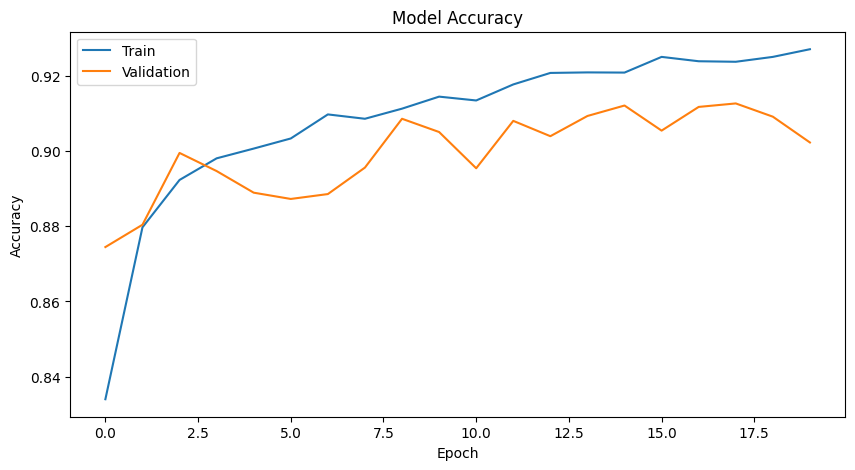

In [24]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])

plt.show()

In [25]:
 #ACCURACY GRAPH

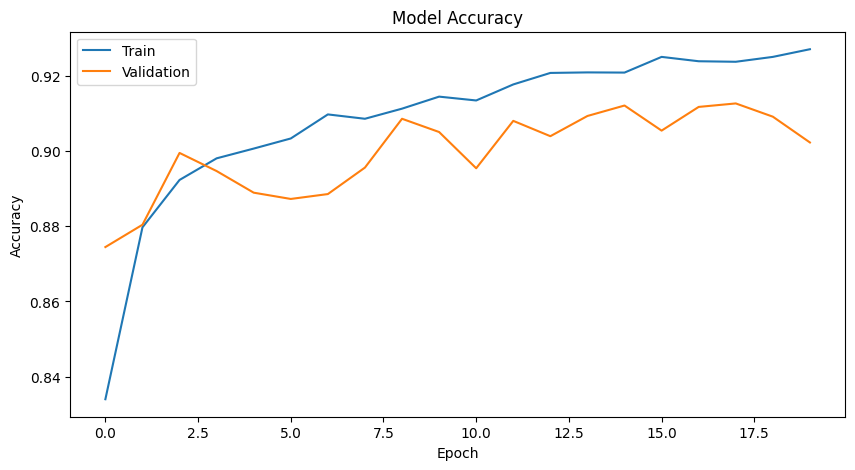

In [26]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])

plt.show()

LOSS GRAPH

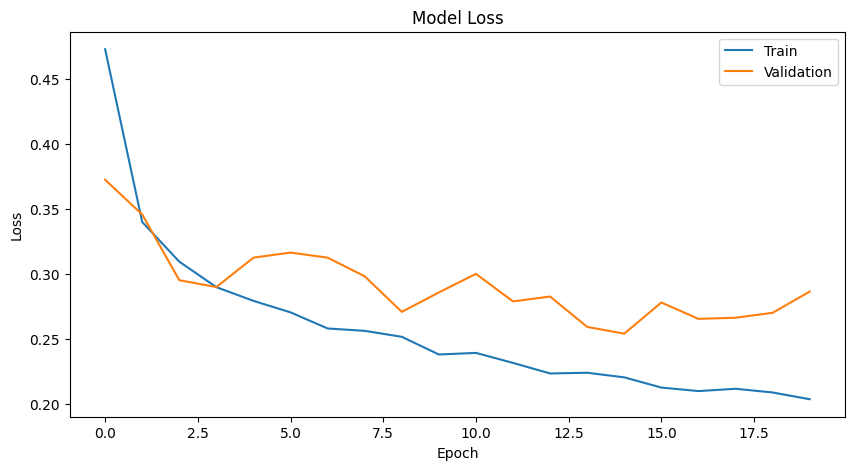

In [27]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(['Train', 'Validation'])

plt.show()

CONFUSION MATRIX

169/169 [==============================] - 34s 196ms/step


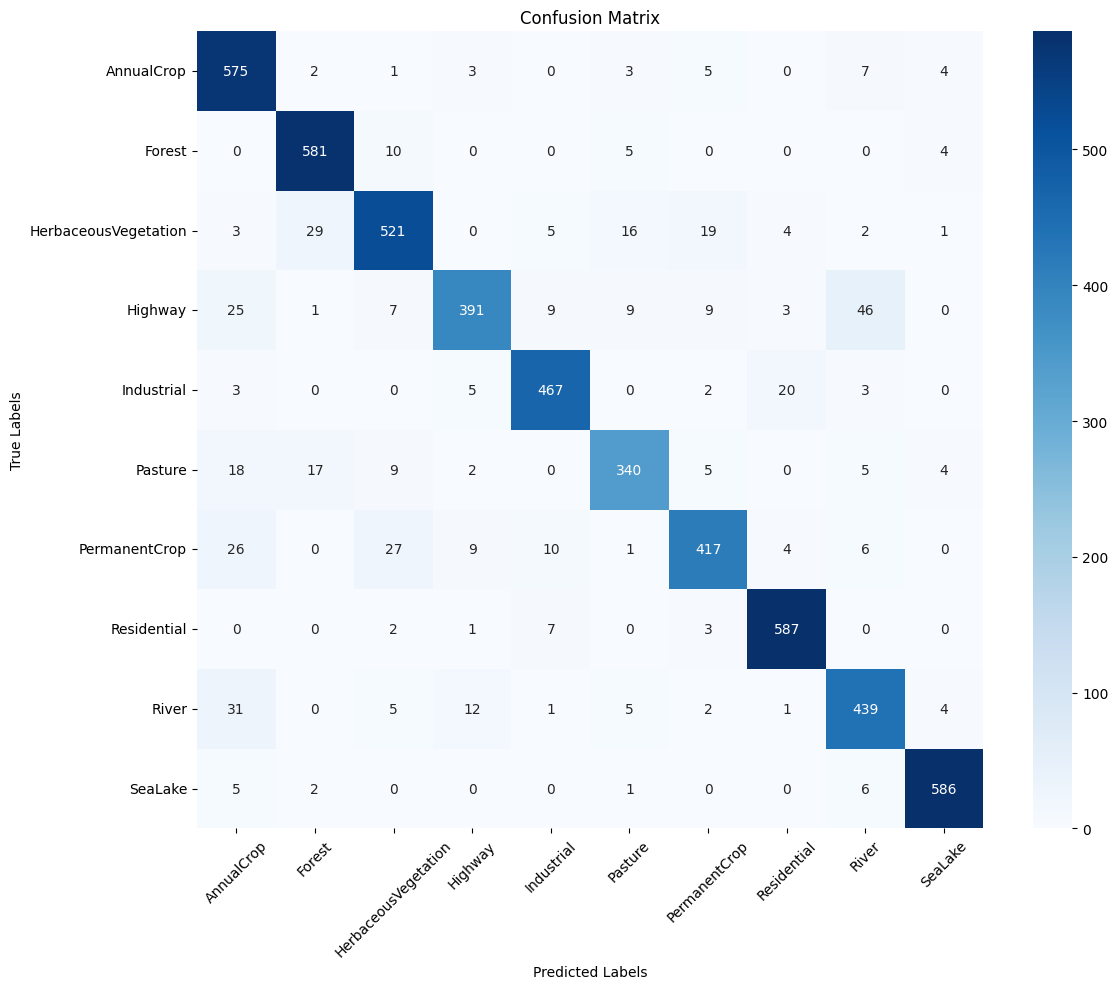

In [28]:
val_data.reset()

predictions = model.predict(val_data)

y_pred = np.argmax(predictions, axis=1)

y_true = val_data.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_name,
    yticklabels=class_name
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Labels")

plt.ylabel("True Labels")

plt.xticks(rotation=45)

plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

CLASSIFICATION REPORT

In [29]:
print("\nClassification Report:\n")

print(classification_report(
    y_true,
    y_pred,
    target_names=class_name
))


Classification Report:

                      precision    recall  f1-score   support

          AnnualCrop       0.84      0.96      0.89       600
              Forest       0.92      0.97      0.94       600
HerbaceousVegetation       0.90      0.87      0.88       600
             Highway       0.92      0.78      0.85       500
          Industrial       0.94      0.93      0.93       500
             Pasture       0.89      0.85      0.87       400
       PermanentCrop       0.90      0.83      0.87       500
         Residential       0.95      0.98      0.96       600
               River       0.85      0.88      0.87       500
             SeaLake       0.97      0.98      0.97       600

            accuracy                           0.91      5400
           macro avg       0.91      0.90      0.90      5400
        weighted avg       0.91      0.91      0.91      5400



 IMAGE PREDICTION FUNCTION

In [30]:
def predict_image(img_path):

    img = image.load_img(
        img_path,
        target_size=(IMG_SIZE, IMG_SIZE)
    )

    img_array = image.img_to_array(img)

    img_array = np.expand_dims(img_array, axis=0)

    img_array = img_array / 255.0

    prediction = model.predict(img_array)

    predicted_class = class_name[np.argmax(prediction)]

    confidence = np.max(prediction) * 100

    print("\nPrediction Result")
    print("-------------------------")
    print("Predicted Class :", predicted_class)
    print("Confidence      : {:.2f}%".format(confidence))

EST PREDICTION


 Example:
predict_image("test.jpg")


# GRAD-CAM HEATMAP

In [31]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)

        pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0,1,2)
    )

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0)

    heatmap = heatmap / np.max(heatmap)

    return heatmap.numpy()


 DISPLAY GRAD-CAM

In [35]:
def display_gradcam(img_array):

    # Get base model
    base_model = model.layers[0]

    # Last convolution layer
    last_conv_layer = base_model.get_layer("Conv_1")

    # Create grad model
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[
            last_conv_layer.output,
            model.output
        ]
    )

    # Gradient computation
    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)

        pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    # Compute gradients
    grads = tape.gradient(class_channel, conv_outputs)

    # Average gradients
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    conv_outputs = conv_outputs[0]

    # Weighted sum
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    # Normalize
    heatmap = np.maximum(heatmap, 0)

    heatmap = heatmap / np.max(heatmap)

    return heatmap.numpy()

 TEST HEATMAP

In [33]:
plt.show()